In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import lightgbm as lgb
import optuna
import shap

from sklearn.metrics import (
    f1_score,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    confusion_matrix,
    classification_report,
)

import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
DATASET_PATH = "/kaggle/input/datasets/jasonkmrkn/fp-ml-sba-artifacts"

In [2]:
X_train = pd.read_parquet(
    f"{DATASET_PATH}/X_train_encoded.parquet"
)

X_val = pd.read_parquet(
    f"{DATASET_PATH}/X_val_encoded.parquet"
)

X_test = pd.read_parquet(
    f"{DATASET_PATH}/X_test_encoded.parquet"
)

y_train = pd.read_parquet(
    f"{DATASET_PATH}/y_train.parquet"
)["Default"]

y_val = pd.read_parquet(
    f"{DATASET_PATH}/y_val.parquet"
)["Default"]

y_test = pd.read_parquet(
    f"{DATASET_PATH}/y_test.parquet"
)["Default"]

print("=== DATA LOADED ===")
print(f"X_train : {X_train.shape}")
print(f"X_val   : {X_val.shape}")
print(f"X_test  : {X_test.shape}")

print()
print("Default Rate")
print(y_train.mean())

=== DATA LOADED ===
X_train : (174993, 46)
X_val   : (37507, 46)
X_test  : (37500, 46)

Default Rate
0.17558988073808668


In [3]:
print(f"Number of features: {X_train.shape[1]}")
print()

for col in X_train.columns:
    print(col)

Number of features: 46

State
Bank
BankState
Term
NoEmp
CreateJob
RetainedJob
RevLineCr
LowDoc
New
RealEstate
IsFranchise
Recession
Portion
SameBankState
LoanSize_log
ApprovalYear
JobsPerLoan
Industry_0
Industry_11
Industry_21
Industry_22
Industry_23
Industry_31
Industry_32
Industry_33
Industry_42
Industry_44
Industry_45
Industry_48
Industry_49
Industry_51
Industry_52
Industry_53
Industry_54
Industry_55
Industry_56
Industry_61
Industry_62
Industry_71
Industry_72
Industry_81
Industry_92
UrbanRural_0
UrbanRural_1
UrbanRural_2


In [4]:
baseline_model = lgb.LGBMClassifier(
    objective="binary",
    n_estimators=100,
    learning_rate=0.1,
    random_state=SEED,
    scale_pos_weight=(
        (y_train == 0).sum()
        /
        (y_train == 1).sum()
    )
)

baseline_model.fit(
    X_train,
    y_train
)

[LightGBM] [Info] Number of positive: 30727, number of negative: 144266
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.019548 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1903
[LightGBM] [Info] Number of data points in the train set: 174993, number of used features: 46
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.175590 -> initscore=-1.546517
[LightGBM] [Info] Start training from score -1.546517


LGBMClassifier(objective='binary', random_state=42,
               scale_pos_weight=np.float64(4.695089009665766))

In [5]:
val_proba = baseline_model.predict_proba(X_val)[:, 1]

val_pred = (
    val_proba >= 0.5
).astype(int)

baseline_f1 = f1_score(
    y_val,
    val_pred
)

baseline_roc = roc_auc_score(
    y_val,
    val_proba
)

baseline_pr = average_precision_score(
    y_val,
    val_proba
)

print("=== BASELINE ===")
print("F1      :", baseline_f1)
print("ROC-AUC :", baseline_roc)
print("PR-AUC  :", baseline_pr)

=== BASELINE ===
F1      : 0.8264140803439474
ROC-AUC : 0.9794615089993599
PR-AUC  : 0.9159739450748141


In [6]:
def objective(trial):

    params = {

        "objective": "binary",
        "metric": "binary_logloss",

        "learning_rate":
            trial.suggest_float(
                "learning_rate",
                0.01,
                0.3,
                log=True
            ),

        "num_leaves":
            trial.suggest_int(
                "num_leaves",
                15,
                255
            ),

        "max_depth":
            trial.suggest_int(
                "max_depth",
                3,
                12
            ),

        "min_child_samples":
            trial.suggest_int(
                "min_child_samples",
                5,
                100
            ),

        "subsample":
            trial.suggest_float(
                "subsample",
                0.5,
                1.0
            ),

        "colsample_bytree":
            trial.suggest_float(
                "colsample_bytree",
                0.5,
                1.0
            ),

        "reg_alpha":
            trial.suggest_float(
                "reg_alpha",
                1e-8,
                10,
                log=True
            ),

        "reg_lambda":
            trial.suggest_float(
                "reg_lambda",
                1e-8,
                10,
                log=True
            ),

        "random_state": SEED,

        "verbose": -1,

        "scale_pos_weight":
            (
                (y_train == 0).sum()
                /
                (y_train == 1).sum()
            )
    }

    model = lgb.LGBMClassifier(
        **params,
        n_estimators=2000
    )

    model.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(
                50,
                verbose=False
            )
        ]
    )

    val_proba = model.predict_proba(
        X_val
    )[:,1]

    val_pred = (
        val_proba >= 0.5
    ).astype(int)

    return f1_score(
        y_val,
        val_pred
    )

In [7]:
study = optuna.create_study(
    direction="maximize"
)

study.optimize(
    objective,
    n_trials=50
)

print("Best F1:")
print(study.best_value)

print()
print("Best Params:")
print(study.best_params)

[I 2026-06-10 06:28:08,047] A new study created in memory with name: no-name-b7319de0-0e0b-406d-8b30-79222b9fd369
[I 2026-06-10 06:28:44,273] Trial 0 finished with value: 0.840472774475644 and parameters: {'learning_rate': 0.011918860124815016, 'num_leaves': 180, 'max_depth': 6, 'min_child_samples': 22, 'subsample': 0.822395721971177, 'colsample_bytree': 0.7088331978019058, 'reg_alpha': 1.1646079248753764e-05, 'reg_lambda': 6.547922218026382e-08}. Best is trial 0 with value: 0.840472774475644.
[I 2026-06-10 06:29:06,979] Trial 1 finished with value: 0.8696863090002932 and parameters: {'learning_rate': 0.09481265840091119, 'num_leaves': 90, 'max_depth': 11, 'min_child_samples': 28, 'subsample': 0.7364701899295254, 'colsample_bytree': 0.5526350946067324, 'reg_alpha': 0.000312458296002333, 'reg_lambda': 0.08514989245310073}. Best is trial 1 with value: 0.8696863090002932.
[I 2026-06-10 06:29:41,718] Trial 2 finished with value: 0.8708029197080291 and parameters: {'learning_rate': 0.061462

Best F1:
0.8723109458178371

Best Params:
{'learning_rate': 0.039303372876555324, 'num_leaves': 129, 'max_depth': 12, 'min_child_samples': 56, 'subsample': 0.8183207260289109, 'colsample_bytree': 0.6233715041017046, 'reg_alpha': 2.416553846818575, 'reg_lambda': 0.03639573340075833}


In [ ]:
best_params = study.best_params

best_model = lgb.LGBMClassifier(
    objective="binary",
    random_state=SEED,

    scale_pos_weight=
    (
        (y_train == 0).sum()
        /
        (y_train == 1).sum()
    ),

    **best_params
)

best_model.fit(
    X_train,
    y_train
)

LGBMClassifier(colsample_bytree=0.6233715041017046,
               learning_rate=0.039303372876555324, max_depth=12,
               min_child_samples=56, num_leaves=129, objective='binary',
               random_state=42, reg_alpha=2.416553846818575,
               reg_lambda=0.03639573340075833,
               scale_pos_weight=np.float64(4.695089009665766),
               subsample=0.8183207260289109)

In [10]:
val_proba = best_model.predict_proba(
    X_val
)[:,1]

precision, recall, thresholds = (
    precision_recall_curve(
        y_val,
        val_proba
    )
)

f1_scores = (
    2 * precision * recall
) / (
    precision + recall + 1e-10
)

best_idx = np.argmax(
    f1_scores[:-1]
)

best_threshold = thresholds[
    best_idx
]

print("Best Threshold:")
print(best_threshold)

print()
print("Validation F1:")
print(f1_scores[best_idx])

Best Threshold:
0.6784264638740887

Validation F1:
0.8546541669242761


In [11]:
test_proba = best_model.predict_proba(
    X_test
)[:,1]

test_pred = (
    test_proba >= best_threshold
).astype(int)

f1 = f1_score(
    y_test,
    test_pred
)

roc = roc_auc_score(
    y_test,
    test_proba
)

pr = average_precision_score(
    y_test,
    test_proba
)

print("=== FINAL TEST ===")
print("F1      :", f1)
print("ROC-AUC :", roc)
print("PR-AUC  :", pr)

=== FINAL TEST ===
F1      : 0.8597910843018979
ROC-AUC : 0.9806963124573945
PR-AUC  : 0.9191163205796157


In [12]:
print(
    classification_report(
        y_test,
        test_pred
    )
)

              precision    recall  f1-score   support

           0       0.98      0.96      0.97     30915
           1       0.83      0.89      0.86      6585

    accuracy                           0.95     37500
   macro avg       0.90      0.92      0.91     37500
weighted avg       0.95      0.95      0.95     37500



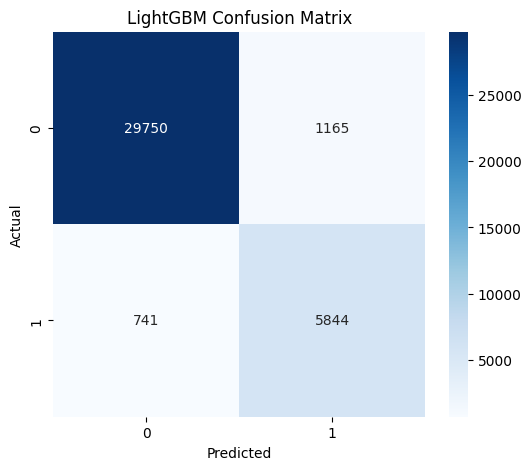

In [13]:
cm = confusion_matrix(
    y_test,
    test_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "LightGBM Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [14]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
3,Term,3556
1,Bank,1560
15,LoanSize_log,1404
2,BankState,1125
16,ApprovalYear,1097
13,Portion,897
0,State,724
4,NoEmp,411
7,RevLineCr,348
17,JobsPerLoan,227


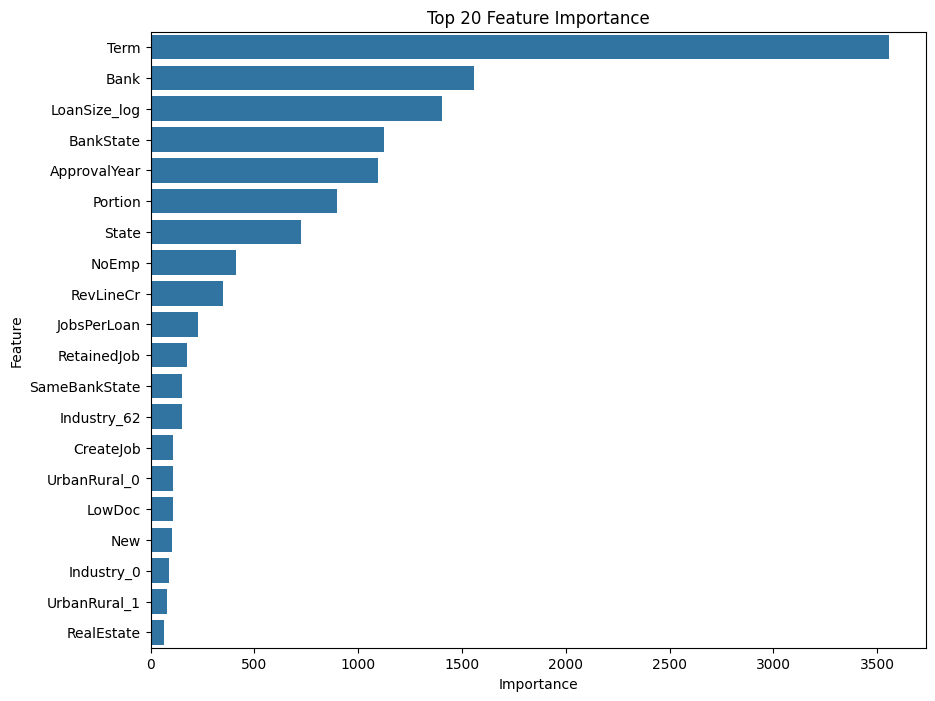

In [15]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=importance.head(20),
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 20 Feature Importance"
)

plt.show()

In [16]:
sample_X = X_test.sample(
    5000,
    random_state=SEED
)

explainer = shap.TreeExplainer(
    best_model
)

shap_values = explainer.shap_values(
    sample_X
)

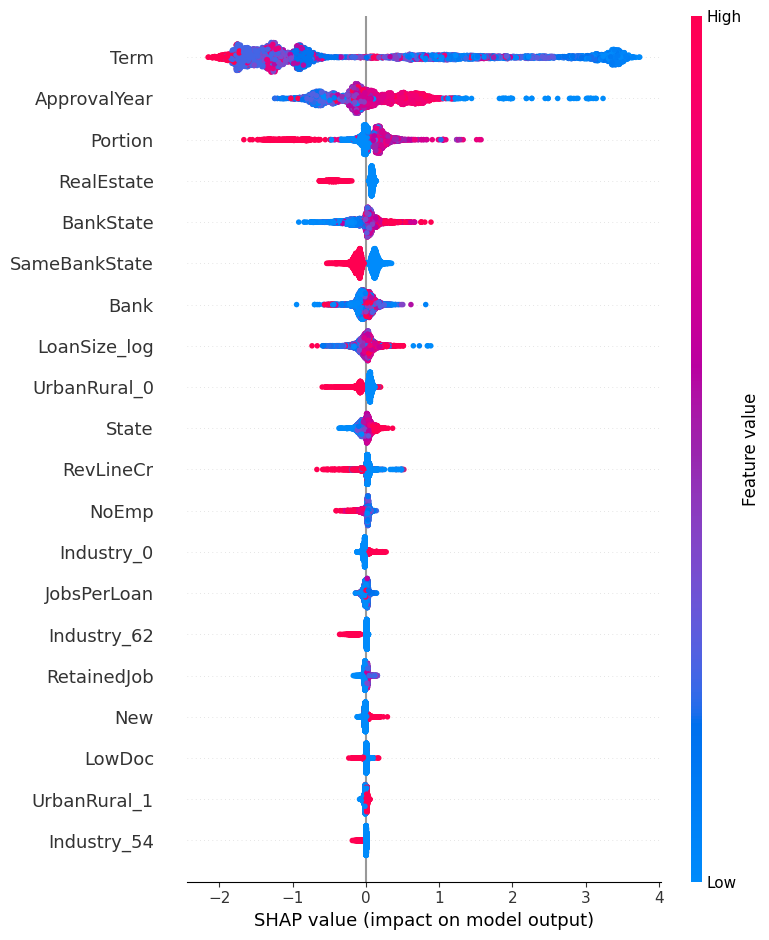

In [17]:
shap.summary_plot(
    shap_values,
    sample_X
)

In [19]:
results = pd.DataFrame({
    "Metric": [
        "F1",
        "ROC_AUC",
        "PR_AUC",
        "Best_Threshold"
    ],
    "Value": [
        f1,
        roc,
        pr,
        best_threshold
    ]
})

results.to_csv(
    "lightgbm_results.csv",
    index=False
)

results

,Metric,Value
0,F1,0.859791
1,ROC_AUC,0.980696
2,PR_AUC,0.919116
3,Best_Threshold,0.678426
